In [1]:
%reset -f

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score




In [3]:
np.random.seed(42)
n = 200

data = pd.DataFrame({
    'account_age':   np.random.randint(1, 60, n),
    'monthly_bill':  np.round(np.random.uniform(20, 200, n), 2),
    'support_calls': np.random.randint(0, 10, n),
    'contract':      np.random.randint(0, 2, n),
    'churn':         np.random.choice([0, 1], n, p=[0.85, 0.15])
})

print(data.describe())
print("Churn rate:", data['churn'].mean().round(3))

       account_age  monthly_bill  support_calls    contract       churn
count   200.000000    200.000000      200.00000  200.000000  200.000000
mean     29.190000    108.494100        4.60500    0.475000    0.120000
std      16.735119     51.305718        3.00234    0.500628    0.325777
min       1.000000     20.090000        0.00000    0.000000    0.000000
25%      15.000000     66.027500        2.00000    0.000000    0.000000
50%      28.500000    102.245000        4.00000    0.000000    0.000000
75%      43.250000    148.315000        7.00000    1.000000    0.000000
max      59.000000    199.590000        9.00000    1.000000    1.000000
Churn rate: 0.12


### Question 1.2

In [4]:
data.groupby('churn')['monthly_bill'].mean()

churn
0    109.097500
1    104.069167
Name: monthly_bill, dtype: float64

### Question 2.2

In [5]:
X = data[['account_age', 'monthly_bill',
          'support_calls', 'contract']].values
y = data['churn'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = SGDClassifier(
    loss='log_loss',
    learning_rate='optimal',
    max_iter=200,
    random_state=42
)

clf.fit(X_train, y_train)

print(classification_report(y_test, clf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.83      0.43      0.57        35
           1       0.09      0.40      0.15         5

    accuracy                           0.42        40
   macro avg       0.46      0.41      0.36        40
weighted avg       0.74      0.42      0.51        40



#### Part C

In [6]:
clf_balanced = SGDClassifier(
    loss='log_loss',
    learning_rate='optimal',
    max_iter=200,
    class_weight='balanced',
    random_state=42
)

clf_balanced.fit(X_train, y_train)

print("With class balancing")
print(classification_report(y_test, clf_balanced.predict(X_test)))

With class balancing
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        35
           1       0.25      0.40      0.31         5

    accuracy                           0.78        40
   macro avg       0.58      0.61      0.59        40
weighted avg       0.82      0.78      0.80        40



### Question 3.2

In [7]:
svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)

proba = svm.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)

print(f"RBF-SVM AUC: {auc:.3f}")
print(f"Support vectors per class: {svm.n_support_}")

RBF-SVM AUC: 0.069
Support vectors per class: [48 19]


#### Part C

In [8]:
grid_inputs = {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1]}

svm_grid = GridSearchCV(
    estimator=SVC(
        kernel='rbf',
        probability=True,
        random_state=42),
    param_grid = grid_inputs,
    scoring='roc_auc',
    cv=5)

svm_grid.fit(X_train, y_train)

print("Best parameters:", svm_grid.best_params_)
print("Best CV AUC:", svm_grid.best_score_)

best_svm = svm_grid.best_estimator_

proba = best_svm.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, proba)

print(f"Test AUC: {test_auc:.3f}")
print(f"Support vectors per class: {best_svm.n_support_}")

Best parameters: {'C': 0.1, 'gamma': 1}
Best CV AUC: 0.49478653530377664
Test AUC: 0.051
Support vectors per class: [60 19]


### Question 4.2

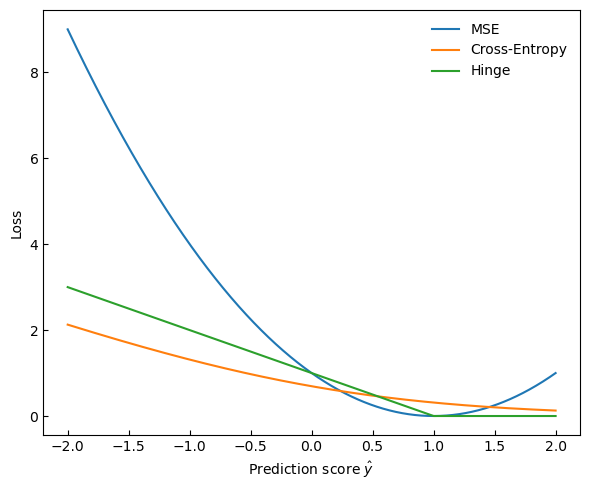

In [9]:
y_hat = np.linspace(-2, 2,1000)
y = 1

mse_loss = (y - y_hat) ** 2

sigmoid = 1 / (1 + np.exp(-y_hat))
cross_entropy_loss = -np.log(sigmoid)

hinge_loss = np.maximum(0, 1 - y * y_hat)


plt.figure(figsize=(6, 5))

plt.plot(y_hat, mse_loss, label="MSE")
plt.plot(y_hat, cross_entropy_loss, label="Cross-Entropy")
plt.plot(y_hat, hinge_loss, label="Hinge")

plt.xlabel(r"Prediction score $\hat{y}$")
plt.ylabel("Loss")

plt.grid(False)
plt.tick_params(axis='both', which='major', direction='in')
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    
plt.legend(frameon=False)
plt.tight_layout()
plt.savefig('Q4.2.png')
plt.show()

### Question 5.1

#### Part b

Explained Variance Ratio:
[0.32026594 0.24753238 0.22945701 0.20274467]

Cumulative Variance:
[0.32026594 0.56779833 0.79725533 1.        ]

Components needed for 90% variance: 4


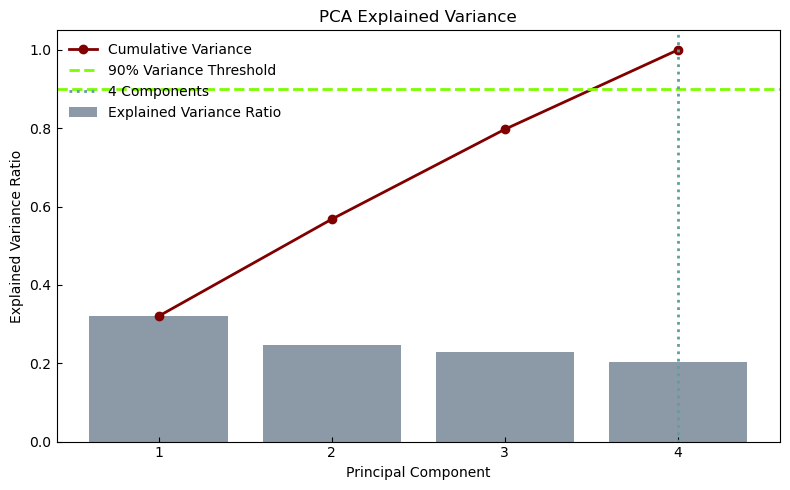

In [10]:
pca = PCA()
pca.fit(X_train)

var = pca.explained_variance_ratio_
cum_var = np.cumsum(var)
n90 = np.argmax(cum_var >= 0.90) + 1

print("Explained Variance Ratio:")
print(var)

print("\nCumulative Variance:")
print(cum_var)

print(f"\nComponents needed for 90% variance: {n90}")

x = np.arange(1, len(var) + 1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x, var, color="slategrey", alpha=0.8, label="Explained Variance Ratio")
ax.plot(x, cum_var, marker="o", color="maroon", linewidth=2, label="Cumulative Variance")

ax.axhline(0.90, color="lawngreen", linestyle="--", linewidth=2, label="90% Variance Threshold")
ax.axvline(n90, color="cadetblue", linestyle=":", linewidth=2, label=f"{n90} Components")

ax.set(
    xlabel="Principal Component",
    ylabel="Explained Variance Ratio",
    title="PCA Explained Variance"
)

ax.set_xticks(x)
ax.grid(False)
ax.tick_params(axis="both", which="major", direction="in")

for spine in ax.spines.values():
    spine.set_visible(True)

ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('PCA.png')
plt.show()

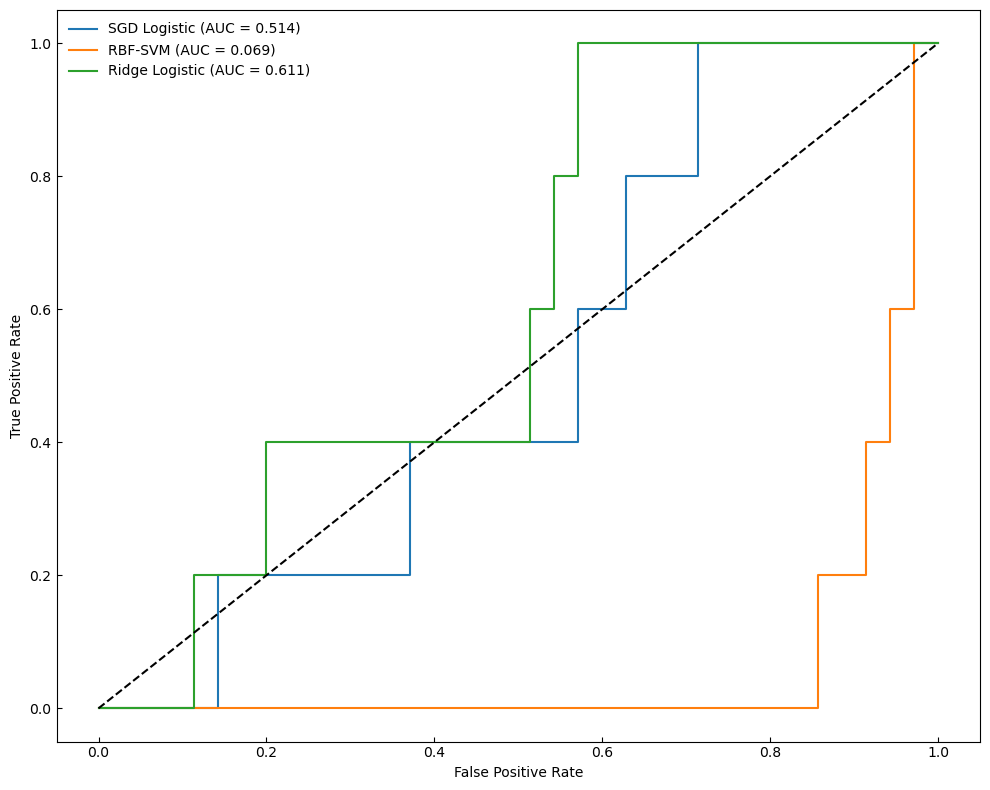

In [11]:
models = {
    "SGD Logistic": SGDClassifier(
        loss="log_loss",
        learning_rate="optimal",
        max_iter=200,
        random_state=42
    ),
    "RBF-SVM": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=42
    ),
    "Ridge Logistic": LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=200,
        random_state=42
    )
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, probability)
    fpr, tpr, _ = roc_curve(y_test, probability)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="black")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(frameon=False)
plt.grid(False)
plt.tick_params(axis="both", which="major", direction="in")

plt.tight_layout()
plt.savefig('ROC.png')
plt.show()
